# Identifying the most important features / drivers of default

This notebook uses logistic regression (LR) to evaluate feature importance and
test for interaction effects. LR is chosen because its coefficients provide
direct, interpretable measures of how each feature influences the log-odds
of loan default, and whether that influence differs across demographic groups
(i.e., bias).

## Data used

- **Input:** `data/raw/loan_data_hard_filtered.csv` (44,993 rows — raw data minus 7 impossible records)
- **NOT used:** The IForest soft-removal (the 5% flagged). Those borderline-unusual rows carry
  important signal for bias analysis and LR is robust enough to handle them.

## Three-step procedure

1. **Full main-effects model** — all 12 features, no interactions (baseline)
2. **Theory-driven interaction testing** — 12 demographic × financial pairs, LRT with Bonferroni correction
3. **Backward elimination** — drop non-significant main effects one at a time via LRT

### Feature interaction methodology
With 12 original features, there are C(12,2) = 66 possible two-way interactions.
Testing all 66 at α = 0.05 would produce ~3.3 false positives by chance, requiring
Bonferroni α ≈ 0.00076 — very conservative. Instead we test only the 12 interactions
that are scientifically motivated by the bias detection goal: **demographic × financial** pairs.
Bonferroni threshold: α = 0.05 / 12 ≈ 0.00417.

### Interactions tested

| # | Interaction | Demographic Feature | Financial Feature |
|---|---|---|---|
| 1 | Gender × Income | `person_gender` | `person_income` |
| 2 | Gender × Credit Score | `person_gender` | `credit_score` |
| 3 | Gender × Interest Rate | `person_gender` | `loan_int_rate` |
| 4 | Gender × Employment Exp. | `person_gender` | `person_emp_exp` |
| 5 | Education × Income | `person_education` | `person_income` |
| 6 | Education × Credit Score | `person_education` | `credit_score` |
| 7 | Education × Interest Rate | `person_education` | `loan_int_rate` |
| 8 | Home Ownership × Income | `person_home_ownership` | `person_income` |
| 9 | Home Ownership × Credit Score | `person_home_ownership` | `credit_score` |
| 10 | Age × Income | `person_age` | `person_income` |
| 11 | Age × Credit Score | `person_age` | `credit_score` |
| 12 | Age × Interest Rate | `person_age` | `loan_int_rate` |

**Intentionally excluded:**
- Financial × financial interactions (e.g. `loan_int_rate × credit_score`) — not relevant to bias detection
- `loan_intent` interactions — a borrower *choice* variable, not a demographic attribute
- `loan_percent_income` interactions — already collinear with `person_income`
- `previous_loan_defaults_on_file` interactions — causes quasi-separation/failure to converge

### Reference categories (statsmodels picks alphabetically first)
- **person_gender**: `female`
- **person_education**: `Associate`
- **person_home_ownership**: `MORTGAGE`
- **loan_intent**: `DEBTCONSOLIDATION`
- **previous_loan_defaults_on_file**: `No`


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path("..")
FILTERED_RAW = PROJECT_ROOT / "data" / "raw" / "loan_data_hard_filtered.csv"

print("Input file:", FILTERED_RAW)
print("Exists:", FILTERED_RAW.exists())

Input file: ../data/raw/loan_data_hard_filtered.csv
Exists: True


## 1. Load data

In [15]:
df = pd.read_csv(FILTERED_RAW)
print(f"Shape: {df.shape}")
print(f"\nTarget distribution (loan_status):")
vc = df['loan_status'].value_counts(normalize=True)
print(f"  Paid    (0): {vc.get(0,0)*100:.1f}%")
print(f"  Default (1): {vc.get(1,0)*100:.1f}%")
df.head()

Shape: (44993, 14)

Target distribution (loan_status):
  Paid    (0): 77.8%
  Default (1): 22.2%


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 2. Full main-effects model (baseline)

Eleven features included, no interaction terms.
Previous loan defaults are excluded since we are missing examples of people with prior defaults that defaulted again.
Since loan_percent_income = loan_amnt / person_income, there are only 2 independent features here. We drop loan_amnt.
Categorical features are declared with `C()` — statsmodels automatically
creates dummy variables internally (no manual one-hot encoding needed).

In [16]:
FORMULA_MAIN = (
    "loan_status ~ "
    "person_age + person_income + person_emp_exp + "
    "loan_int_rate + loan_percent_income + "
    "cb_person_cred_hist_length + credit_score + "
    "C(person_gender) + C(person_education) + "
    "C(person_home_ownership) + C(loan_intent)"
    # previous_loan_defaults_on_file removed — causes quasi-separation
)

m0 = smf.logit(FORMULA_MAIN, data=df).fit(disp=0)
print(m0.summary())
print(f"\nBaseline — Log-likelihood: {m0.llf:.2f} | AIC: {m0.aic:.2f} | Pseudo-R² (McFadden): {m0.prsquared:.4f}")

                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                44993
Model:                          Logit   Df Residuals:                    44972
Method:                           MLE   Df Model:                           20
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.3058
Time:                        12:36:18   Log-Likelihood:                -16546.
converged:                       True   LL-Null:                       -23835.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -5.9220      0.273    -21.721      0.000      -6.456      -5.388
C(person_gender)[T.male]               0.0069      0.028   

## 3. Multicollinearity check (VIF)

Age and employment experience are naturally highly correlated and this is the main source of collinearity.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = [
    'person_age', 'person_income', 'person_emp_exp',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'
]

df_std = df.copy()
for col in numeric_cols:
    df_std[col] = (df[col] - df[col].mean()) / df[col].std()

vif_data = df_std[numeric_cols].copy()
vif_data['const'] = 1.0

vif = pd.DataFrame({
    'Feature': numeric_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(numeric_cols))]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factors (VIF > 10 = serious multicollinearity):")
print(vif.to_string(index=False))


Variance Inflation Factors (VIF > 10 = serious multicollinearity):
                   Feature       VIF
                person_age 13.894721
            person_emp_exp 10.777003
cb_person_cred_hist_length  4.390615
             person_income  1.112653
       loan_percent_income  1.108899
              credit_score  1.034603
             loan_int_rate  1.017882


## 4. Theory-driven interaction testing

For each candidate interaction, we fit a model that adds the interaction to the
baseline main-effects model, then compare via **Likelihood Ratio Test (LRT)**:

$$\text{LR} = 2(\ell_1 - \ell_0) \sim \chi^2(\Delta k)$$

where $\Delta k$ is the number of parameters added (= number of levels − 1 for a categorical).

**Bonferroni-corrected threshold:** α = 0.05 / 12 ≈ 0.00417

In [18]:
INTERACTIONS = [
    # (formula term,                                     display label)
    ("C(person_gender):person_income",              "Gender × Income"),
    ("C(person_gender):credit_score",               "Gender × Credit Score"),
    ("C(person_gender):loan_int_rate",              "Gender × Interest Rate"),
    ("C(person_gender):person_emp_exp",             "Gender × Employment Exp."),
    ("C(person_education):person_income",           "Education × Income"),
    ("C(person_education):credit_score",            "Education × Credit Score"),
    ("C(person_education):loan_int_rate",           "Education × Interest Rate"),
    ("C(person_home_ownership):person_income",      "Home Ownership × Income"),
    ("C(person_home_ownership):credit_score",       "Home Ownership × Credit Score"),
    ("person_age:person_income",                    "Age × Income"),
    ("person_age:credit_score",                     "Age × Credit Score"),
    ("person_age:loan_int_rate",                    "Age × Interest Rate"),
]

N_TESTS    = len(INTERACTIONS)
ALPHA_BONF = 0.05 / N_TESTS
print(f"Testing {N_TESTS} interactions | Bonferroni α = 0.05/{N_TESTS} = {ALPHA_BONF:.5f}\n")

results = []
for term, label in INTERACTIONS:
    formula_with = FORMULA_MAIN + f" + {term}"
    m1 = smf.logit(formula_with, data=df).fit(disp=0)
    df_diff = len(m1.params) - len(m0.params)
    lr_stat = 2 * (m1.llf - m0.llf)
    p_val   = stats.chi2.sf(lr_stat, df=df_diff)
    results.append({
        'Interaction': label,
        'Term':        term,
        'ΔParams':     df_diff,
        'LR Stat':     round(lr_stat, 3),
        'p-value':     p_val,
        'Sig (Bonf.)': '✅' if p_val < ALPHA_BONF else '—',
    })

results_df = pd.DataFrame(results).sort_values('p-value')

display_df = results_df[['Interaction', 'ΔParams', 'LR Stat', 'p-value', 'Sig (Bonf.)']].copy()
display_df['p-value'] = display_df['p-value'].apply(lambda p: f"{p:.2e}")
print(display_df.to_string(index=False))

Testing 12 interactions | Bonferroni α = 0.05/12 = 0.00417

                  Interaction  ΔParams  LR Stat   p-value Sig (Bonf.)
      Home Ownership × Income        3  677.245 1.80e-146           ✅
                 Age × Income        1  102.368  4.61e-24           ✅
           Education × Income        4   28.106  1.19e-05           ✅
          Age × Interest Rate        1    9.997  1.57e-03           ✅
              Gender × Income        1    2.287  1.30e-01           —
       Gender × Interest Rate        1    2.171  1.41e-01           —
Home Ownership × Credit Score        3    3.753  2.89e-01           —
     Gender × Employment Exp.        1    0.856  3.55e-01           —
        Gender × Credit Score        1    0.708  4.00e-01           —
     Education × Credit Score        4    3.958  4.12e-01           —
           Age × Credit Score        1    0.412  5.21e-01           —
    Education × Interest Rate        4    3.178  5.28e-01           —


## 5. Refit model with significant interactions included

Note: Prior Default x Credit score needs to be excluded because it reintroduces the problem where we had no examples of previous loan defaults that default again.

In [19]:
sig_terms = results_df.loc[results_df['p-value'] < ALPHA_BONF, 'Term'].tolist()

if sig_terms:
    print(f"{len(sig_terms)} significant interaction(s) added to model:")
    for t in sig_terms:
        label = results_df.loc[results_df['Term'] == t, 'Interaction'].values[0]
        pval  = results_df.loc[results_df['Term'] == t, 'p-value'].values[0]
        print(f"  + {label}  (p = {pval:.2e})")
    FORMULA_WITH_IX = FORMULA_MAIN + " + " + " + ".join(sig_terms)
else:
    print("No interactions met Bonferroni threshold — proceeding with main-effects model.")
    FORMULA_WITH_IX = FORMULA_MAIN

m_ix = smf.logit(FORMULA_WITH_IX, data=df).fit(disp=0)
print(f"\nWith interactions — Log-likelihood: {m_ix.llf:.2f} | AIC: {m_ix.aic:.2f} | "
      f"Pseudo-R²: {m_ix.prsquared:.4f}")
print(f"Improvement over baseline — ΔLL: {m_ix.llf - m0.llf:.2f} | ΔAIC: {m_ix.aic - m0.aic:.2f}")
print(m_ix.summary())

4 significant interaction(s) added to model:
  + Home Ownership × Income  (p = 1.80e-146)
  + Age × Income  (p = 4.61e-24)
  + Education × Income  (p = 1.19e-05)
  + Age × Interest Rate  (p = 1.57e-03)

With interactions — Log-likelihood: -16183.09 | AIC: 32426.18 | Pseudo-R²: 0.3210
Improvement over baseline — ΔLL: 362.90 | ΔAIC: -707.80
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                44993
Model:                          Logit   Df Residuals:                    44963
Method:                           MLE   Df Model:                           29
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.3210
Time:                        12:37:16   Log-Likelihood:                -16183.
converged:                       True   LL-Null:                       -23835.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           

## 6. Backward elimination

Starting from the model with significant interactions, we remove main-effect terms
one at a time. At each step:
1. For each remaining main-effect term, fit a model without it and run LRT
2. The term whose removal causes the **smallest significant worsening** is a candidate for removal
3. If that term's removal p-value > 0.05 (i.e., removing it does NOT significantly worsen the model), drop it
4. Repeat until all remaining terms are significant

**Note:** We only eliminate main effects — the significant interaction terms from step 4 are kept.

In [20]:
def remove_term_from_formula(formula, term):
    """Remove a single term from a formula string, handling + signs cleanly."""
    lhs, rhs = formula.split('~')
    terms = [t.strip() for t in rhs.split('+')]
    terms = [t for t in terms if t != term.strip()]
    return lhs + '~ ' + ' + '.join(terms)

def lrt_removal_pval(formula_full, term, data):
    """LRT p-value for removing a term from a logistic regression model."""
    formula_reduced = remove_term_from_formula(formula_full, term)
    m_full    = smf.logit(formula_full,    data=data).fit(disp=0)
    m_reduced = smf.logit(formula_reduced, data=data).fit(disp=0)
    df_diff   = len(m_full.params) - len(m_reduced.params)
    lr_stat   = 2 * (m_full.llf - m_reduced.llf)
    p_val     = stats.chi2.sf(lr_stat, df=max(df_diff, 1))
    return p_val, formula_reduced

main_terms = [t.strip() for t in FORMULA_MAIN.split('~')[1].split('+') if t.strip()]
current_formula = FORMULA_WITH_IX

print("=== Backward Elimination (main effects only) ===\n")
iteration = 0

while True:
    iteration += 1
    candidates = []

    for term in main_terms:
        if term not in current_formula:
            continue
        p_val, formula_reduced = lrt_removal_pval(current_formula, term, df)
        candidates.append({'term': term, 'p_removal': p_val,
                            'formula_reduced': formula_reduced})

    if not candidates:
        print("No more candidates.")
        break

    best = max(candidates, key=lambda x: x['p_removal'])

    print(f"Iter {iteration}: Least significant = '{best['term']}'  "
          f"| removal LRT p = {best['p_removal']:.4f}", end="  ")

    if best['p_removal'] > 0.05:
        print("→ Dropped")
        main_terms.remove(best['term'])
        current_formula = best['formula_reduced']
    else:
        print("→ Kept (all remaining terms significant — stopping)")
        break

FINAL_FORMULA = current_formula
FINAL_MODEL   = smf.logit(FINAL_FORMULA, data=df).fit(disp=0)
print(f"\nFinal formula:\n{FINAL_FORMULA}")

=== Backward Elimination (main effects only) ===

Iter 1: Least significant = 'person_income'  | removal LRT p = 1.0000  → Dropped
Iter 2: Least significant = 'C(person_gender)'  | removal LRT p = 0.9071  → Dropped
Iter 3: Least significant = 'cb_person_cred_hist_length'  | removal LRT p = 0.5508  → Dropped
Iter 4: Least significant = 'credit_score'  | removal LRT p = 0.3275  → Dropped
Iter 5: Least significant = 'person_emp_exp'  | removal LRT p = 0.2189  → Dropped
Iter 6: Least significant = 'C(person_education)'  | removal LRT p = 0.0076  → Kept (all remaining terms significant — stopping)

Final formula:
loan_status ~ person_age + loan_int_rate + loan_percent_income + C(person_education) + C(person_home_ownership) + C(loan_intent) + C(person_home_ownership):person_income + person_age:person_income + C(person_education):person_income + person_age:loan_int_rate


## 7. Final model summary

In [21]:
print(FINAL_MODEL.summary())
print(f"\nFinal model — Log-likelihood: {FINAL_MODEL.llf:.2f} | "
      f"AIC: {FINAL_MODEL.aic:.2f} | Pseudo-R²: {FINAL_MODEL.prsquared:.4f}")

                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                44993
Model:                          Logit   Df Residuals:                    44967
Method:                           MLE   Df Model:                           25
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                  0.3210
Time:                        12:38:45   Log-Likelihood:                -16185.
converged:                       True   LL-Null:                       -23835.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           -5.6116      0.328    -17.135      0.000      -6.254      -4.970
C(person_educatio

The above results show log odds. Here is an example of how to interpret those:
loan_percent_income (10.2493): "For every 1% increase in the portion of income dedicated to the loan, the odds of default increase by about 10.7% (
e^10.2493 / 100 = 1.107)."

Note here and below that the features are unscaled, meaning the magnitudes of effect sizes may warp how large the effect sizes actually are.

## 8. Odds ratio plot — final model

Odds ratios (OR = exp(coefficient)) are more interpretable than raw log-odds:
- **OR > 1**: feature increases the probability of default
- **OR < 1**: feature decreases the probability of default
- **OR = 1**: no effect

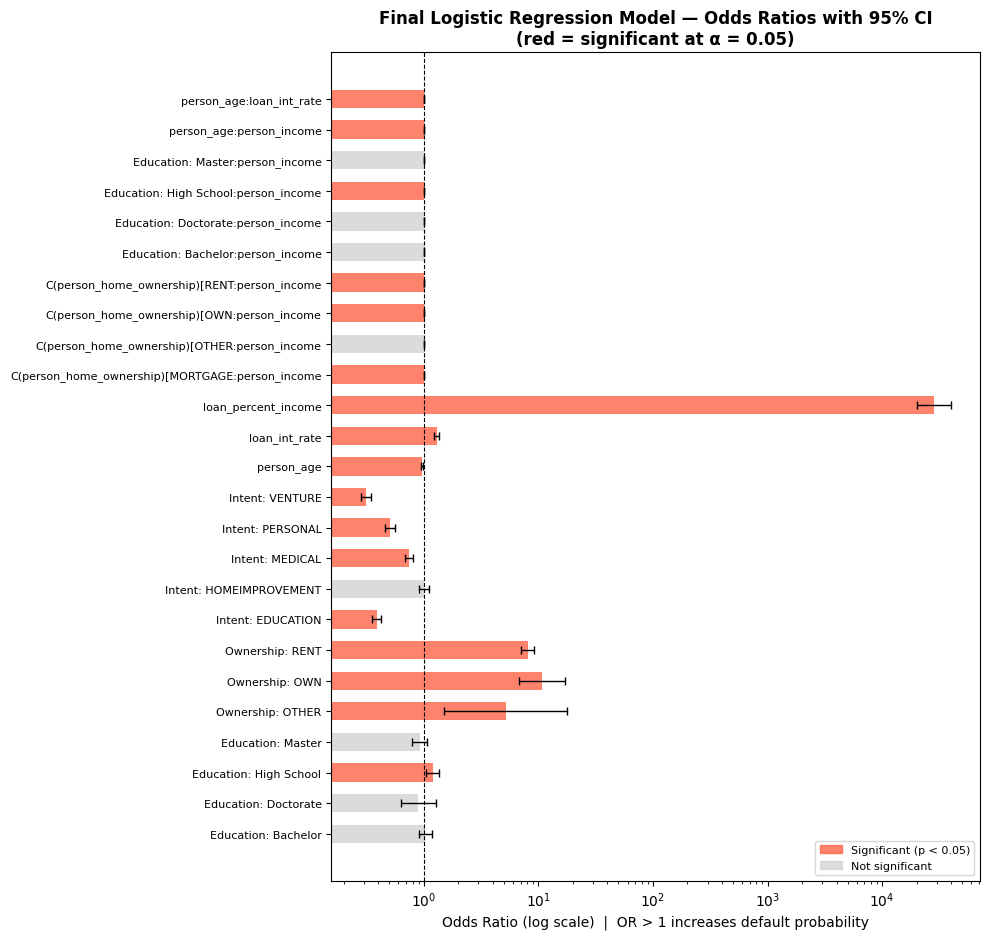

In [22]:
params_f  = FINAL_MODEL.params.drop('Intercept')
conf_f    = FINAL_MODEL.conf_int().drop('Intercept')
pvals_f   = FINAL_MODEL.pvalues.drop('Intercept')

or_vals   = np.exp(params_f)
or_ci_lo  = np.exp(conf_f[0])
or_ci_hi  = np.exp(conf_f[1])
labels_f  = [clean_name(n) for n in params_f.index]
colors_f  = ['tomato' if p < 0.05 else 'lightgrey' for p in pvals_f]

fig, ax = plt.subplots(figsize=(10, max(8, len(labels_f) * 0.38)))
y = range(len(labels_f))
ax.barh(y, or_vals.values, color=colors_f, alpha=0.8, height=0.6)
ax.errorbar(
    or_vals.values, y,
    xerr=[or_vals.values - or_ci_lo.values, or_ci_hi.values - or_vals.values],
    fmt='none', color='black', capsize=3, linewidth=1
)
ax.axvline(1, color='black', linewidth=0.8, linestyle='--', label='OR = 1 (no effect)')
ax.set_yticks(y)
ax.set_yticklabels(labels_f, fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Odds Ratio (log scale)  |  OR > 1 increases default probability')
ax.set_title(
    'Final Logistic Regression Model — Odds Ratios with 95% CI\n'
    '(red = significant at α = 0.05)',
    fontweight='bold'
)
ax.legend(handles=[
    mpatches.Patch(color='tomato',    alpha=0.8, label='Significant (p < 0.05)'),
    mpatches.Patch(color='lightgrey', alpha=0.8, label='Not significant'),
], loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Key findings for bias detection

In [23]:
print("=" * 65)
print("KEY FINDINGS")
print("=" * 65)
print(f"  Baseline model  Pseudo-R²: {m0.prsquared:.4f} | AIC: {m0.aic:.0f}")
print(f"  Final model     Pseudo-R²: {FINAL_MODEL.prsquared:.4f} | AIC: {FINAL_MODEL.aic:.0f}")
print()

demo_keys = ['person_gender', 'person_education', 'person_home_ownership', 'person_age']
bias_interactions = [r for r in results if
                     r['p-value'] < ALPHA_BONF and
                     any(d in r['Term'] for d in demo_keys)]

print("DEMOGRAPHIC × FINANCIAL INTERACTIONS (bias markers):")
if bias_interactions:
    for r in sorted(bias_interactions, key=lambda x: x['p-value']):
        print(f"  ✅ {r['Interaction']:<35}  p = {r['p-value']:.2e}")
    print()
    print("  → A significant interaction means the effect of a financial feature")
    print("    on default probability DIFFERS by demographic group.")
    print("    This is a statistical marker of potential model bias.")
else:
    print("  No significant demographic × financial interactions found.")
    print("  → LR finds no evidence of differential effects across groups.")
    print("  → Non-linear bias may still be present — check XGBoost feature importance.")

print()
print("LIMITATIONS")
print("  - LR captures linear effects only. Non-linear bias patterns will be missed.")
print("  - XGBoost/NN models may reveal interactions LR cannot detect.")
print("  - Multicollinearity between loan_amnt, person_income, loan_percent_income")
print("    may inflate standard errors for those coefficients.")
print("=" * 65)

KEY FINDINGS
  Baseline model  Pseudo-R²: 0.3058 | AIC: 33134
  Final model     Pseudo-R²: 0.3210 | AIC: 32421

DEMOGRAPHIC × FINANCIAL INTERACTIONS (bias markers):
  ✅ Home Ownership × Income              p = 1.80e-146
  ✅ Age × Income                         p = 4.61e-24
  ✅ Education × Income                   p = 1.19e-05
  ✅ Age × Interest Rate                  p = 1.57e-03

  → A significant interaction means the effect of a financial feature
    on default probability DIFFERS by demographic group.
    This is a statistical marker of potential model bias.

LIMITATIONS
  - LR captures linear effects only. Non-linear bias patterns will be missed.
  - XGBoost/NN models may reveal interactions LR cannot detect.
  - Multicollinearity between loan_amnt, person_income, loan_percent_income
    may inflate standard errors for those coefficients.
